In [1]:
!pip install timm==0.9.16

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 30.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found ex

In [2]:
import csv
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import timm

In [3]:
# class RepVGGB0(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.model = timm.create_model('repvgg_b0', pretrained=False)
#         num_features = self.model.head.in_features
#         self.model.head = nn.Linear(num_features, 2)

#     def forward(self, x):
#         return self.model(x)

In [4]:
import torch
import timm
teacher = timm.create_model('repvgg_b0', pretrained=False, num_classes=2)

state_dict = torch.load("/kaggle/input/repvgg-teacher/REPVGGB0-TEACHER-TRAINV2.pth", map_location='cuda')  # hoặc 'cpu' nếu không dùng GPU

from collections import OrderedDict
new_state_dict = OrderedDict((k.replace("module.", ""), v) for k, v in state_dict.items())
teacher.load_state_dict(new_state_dict)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher = teacher.to(device)
teacher.eval()


ByobNet(
  (stem): RepVggBlock(
    (conv_kxk): ConvNormAct(
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNormAct2d(
        64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Identity()
      )
    )
    (conv_1x1): ConvNormAct(
      (conv): Conv2d(3, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (bn): BatchNormAct2d(
        64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Identity()
      )
    )
    (drop_path): Identity()
    (attn): Identity()
    (act): ReLU(inplace=True)
  )
  (stages): Sequential(
    (0): Sequential(
      (0): RepVggBlock(
        (conv_kxk): ConvNormAct(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          

In [5]:
# import torch.nn as nn
# import timm

# class RepVGGA0(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.model = timm.create_model('repvgg_a0', pretrained=True)
#         num_features = self.model.head.in_features
#         self.model.head = nn.Identity()  # Bỏ lớp classification gốc
#         self.fc = nn.Linear(num_features, 2)  # Thêm lớp phân loại của bạn

#     def forward(self, x):
#         features = self.model(x)               # Output shape: [B, C, H, W] hoặc [B, C]
#         if features.dim() == 4:
#             features = features.mean(dim=[2, 3])  # Global Average Pooling nếu còn chiều H, W
#         out = self.fc(features)                # Linear projection
#         return out


In [6]:
class DistillLoss(nn.Module):
    def __init__(self, T=4.0, alpha=0.7):
        super().__init__()
        self.T = T
        self.alpha = alpha
        self.kld = nn.KLDivLoss(reduction='batchmean')
        self.ce = nn.CrossEntropyLoss()

    def forward(self, student_logits, teacher_logits, true_labels):
        kd = self.kld(F.log_softmax(student_logits / self.T, dim=1),
                      F.softmax(teacher_logits / self.T, dim=1)) * (self.T ** 2)
        ce = self.ce(student_logits, true_labels)
        return self.alpha * kd + (1 - self.alpha) * ce

In [7]:
class CustomRepVGG(nn.Module):
    def __init__(self, model_name='repvgg_a0', num_classes=2):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=True)
        in_features = self.model.head.in_features
        self.model.head = nn.Linear(in_features, num_classes)

    def forward(self, x, return_features=False):
        features = self.model.forward_features(x)  # features: [B, C, H, W]
        pooled = features.mean(dim=[2, 3])  # Global Average Pooling -> [B, C]
        out = self.model.head(pooled)
        if return_features:
            return out, pooled
        return out


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# teacher = CustomRepVGG('repvgg_b0', num_classes=2).to(device)
student = CustomRepVGG('repvgg_a0', num_classes=2).to(device)

model.safetensors:   0%|          | 0.00/36.6M [00:00<?, ?B/s]

In [9]:
from torchvision import datasets

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder("/kaggle/input/fakeface-train-data-v2", transform=transform)
val_dataset   = datasets.ImageFolder("/kaggle/input/fakeface-valid-data-v2", transform=transform)
test_dataset = datasets.ImageFolder("/kaggle/input/fakeface-test-data-v2", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader   = DataLoader(test_dataset, batch_size=64, shuffle=False,num_workers=2)

In [10]:
# teacher = load_teacher_model("/kaggle/input/repvgg/RepVGGB0_Teacher.pth", device="cuda")
# student = RepVGGA0()

if torch.cuda.device_count() > 1:
    print(f"Sử dụng {torch.cuda.device_count()} GPU với DataParallel.")
    student = nn.DataParallel(student)
    teacher = nn.DataParallel(teacher)

kd_loss_fn = DistillLoss(T=4.0, alpha=0.7)
optimizer = torch.optim.Adam(student.parameters(), lr=1e-4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Sử dụng 2 GPU với DataParallel.


In [11]:
student = student.to(device)
teacher = teacher.to(device)

In [12]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

def evaluate_model_on_validation(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = float('nan')

    return acc, auc

In [13]:
import time
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

def train_student_kd_with_validation(student, teacher, train_loader, val_loader, kd_loss_fn, optimizer, device, epochs=10):
    ce_loss_fn = nn.CrossEntropyLoss()
    start_training = time.time()

    for epoch in range(epochs):
        student.train()
        teacher.eval()

        total_kd_loss = 0
        total_student_loss = 0
        total_teacher_loss = 0

        all_probs = []
        all_labels = []

        start_epoch = time.time()

        progress_bar = tqdm(train_loader, desc=f"[Epoch {epoch+1}] Training", leave=False)

        for x, y in progress_bar:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()

            with torch.no_grad():
                t_logits = teacher(x)
                teacher_ce_loss = ce_loss_fn(t_logits, y)

            s_logits = student(x)

            student_ce_loss = ce_loss_fn(s_logits, y)
            kd_loss = kd_loss_fn(s_logits, t_logits, y)

            kd_loss.backward()
            optimizer.step()

            total_kd_loss += kd_loss.item()
            total_student_loss += student_ce_loss.item()
            total_teacher_loss += teacher_ce_loss.item()

            probs = torch.softmax(s_logits, dim=1)[:, 1].detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y.cpu().numpy())

            progress_bar.set_postfix({
                "KD": f"{kd_loss.item():.4f}",
                "StudentCE": f"{student_ce_loss.item():.4f}"
            })

        try:
            train_auc = roc_auc_score(all_labels, all_probs)
        except:
            train_auc = float('nan')

        epoch_time = time.time() - start_epoch

        val_acc, val_auc = evaluate_model_on_validation(student, val_loader, device)

        print(f"[Epoch {epoch+1}] "
              f"KD Loss: {total_kd_loss / len(train_loader):.4f} | "
              f"Train AUC: {train_auc:.4f} | "
              f"Val AUC: {val_auc:.4f} | Val ACC: {val_acc:.4f} | "
              f"Time: {epoch_time:.2f}s")

    total_time = time.time() - start_training
    def count_all_parameters(model):
        return sum(p.numel() for p in model.parameters())

    def count_trainable_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Số tham số (Trainable) của Student: {count_trainable_parameters(student):,}")
    print(f"Tổng số tham số của Student: {count_all_parameters(student):,}")

    print(f"Số tham số (Trainable) của Teacher: {count_trainable_parameters(teacher):,}")
    print(f"Tổng số tham số của Teacher: {count_all_parameters(teacher):,}")
    
    print(f"⏱️ Tổng thời gian training: {total_time:.2f} giây ({total_time/60:.2f} phút)")


In [14]:
from sklearn.metrics import classification_report
import torch

def evaluate_models_report(student, teacher, dataloader, device):
    student.eval()
    teacher.eval()

    all_labels = []
    student_preds = []
    teacher_preds = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            s_logits = student(x)
            t_logits = teacher(x)

            student_cls = torch.argmax(s_logits, dim=1).cpu().numpy()
            teacher_cls = torch.argmax(t_logits, dim=1).cpu().numpy()
            true_labels = y.cpu().numpy()

            student_preds.extend(student_cls)
            teacher_preds.extend(teacher_cls)
            all_labels.extend(true_labels)

    print("📘 [Student Model] Classification Report:")
    print(classification_report(all_labels, student_preds, digits=4))

    print("📗 [Teacher Model] Classification Report:")
    print(classification_report(all_labels, teacher_preds, digits=4))


In [15]:
train_student_kd_with_validation(student, teacher, train_loader, val_loader, kd_loss_fn, optimizer, device, epochs=10)

[Epoch 1] KD Loss: 0.5222 | Train AUC: 0.9448 | Val AUC: 0.9665 | Val ACC: 0.8079 | Time: 524.29s


[Epoch 2] KD Loss: 0.3174 | Train AUC: 0.9678 | Val AUC: 0.9606 | Val ACC: 0.8600 | Time: 460.89s


[Epoch 3] KD Loss: 0.2711 | Train AUC: 0.9705 | Val AUC: 0.9630 | Val ACC: 0.7824 | Time: 461.94s


[Epoch 4] KD Loss: 0.2453 | Train AUC: 0.9714 | Val AUC: 0.9653 | Val ACC: 0.8115 | Time: 461.62s


[Epoch 5] KD Loss: 0.2287 | Train AUC: 0.9720 | Val AUC: 0.9689 | Val ACC: 0.8458 | Time: 461.86s


[Epoch 6] KD Loss: 0.2188 | Train AUC: 0.9723 | Val AUC: 0.9689 | Val ACC: 0.8071 | Time: 460.68s


[Epoch 7] KD Loss: 0.2093 | Train AUC: 0.9727 | Val AUC: 0.9679 | Val ACC: 0.7948 | Time: 460.34s


[Epoch 8] KD Loss: 0.2048 | Train AUC: 0.9726 | Val AUC: 0.9665 | Val ACC: 0.8374 | Time: 461.48s


[Epoch 9] KD Loss: 0.2002 | Train AUC: 0.9727 | Val AUC: 0.9665 | Val ACC: 0.8402 | Time: 463.25s


[Epoch 10] KD Loss: 0.1958 | Train AUC: 0.9727 | Val AUC: 0.9699 | Val ACC: 0.8185 | Time: 460.71s
Số tham số (Trainable) của Student: 7,830,530
Tổng số tham số của Student: 7,830,530
Số tham số (Trainable) của Teacher: 14,539,522
Tổng số tham số của Teacher: 14,539,522
⏱️ Tổng thời gian training: 5536.18 giây (92.27 phút)


In [16]:
evaluate_models_report(student, teacher, test_loader, device)

📘 [Student Model] Classification Report:
              precision    recall  f1-score   support

           0     0.9910    0.6577    0.7907     20000
           1     0.7439    0.9940    0.8509     20000

    accuracy                         0.8259     40000
   macro avg     0.8674    0.8259    0.8208     40000
weighted avg     0.8674    0.8259    0.8208     40000

📗 [Teacher Model] Classification Report:
              precision    recall  f1-score   support

           0     0.9911    0.6345    0.7737     20000
           1     0.7312    0.9943    0.8427     20000

    accuracy                         0.8144     40000
   macro avg     0.8612    0.8144    0.8082     40000
weighted avg     0.8612    0.8144    0.8082     40000



In [17]:
torch.save(student.state_dict(), "/kaggle/working/repvgga0_student.pth")

In [18]:
print(test_dataset.class_to_idx)

{'fake': 0, 'real': 1}


In [19]:
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F

def get_auc(model, dataloader):
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)  # shape: [B, 2]
            probs = F.softmax(outputs, dim=1)[:, 1]  # xác suất class "1" (real)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    return auc


In [20]:
student_auc = get_auc(student, test_loader)
teacher_auc = get_auc(teacher, test_loader)

print(f" Student AUC: {student_auc:.4f}")
print(f" Teacher AUC: {teacher_auc:.4f}")


 Student AUC: 0.9783
 Teacher AUC: 0.9685


In [21]:
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(model, dataloader, model_name="Model"):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)  # shape: [B, 2]
            probs = F.softmax(outputs, dim=1)[:, 1]  # xác suất class 1 (real)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange',
             lw=2, label=f'{model_name} (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


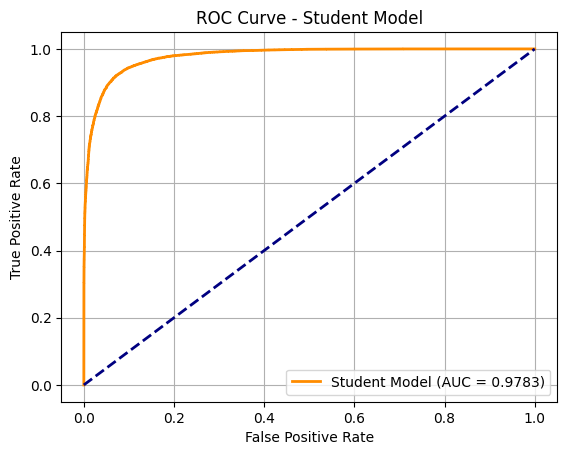

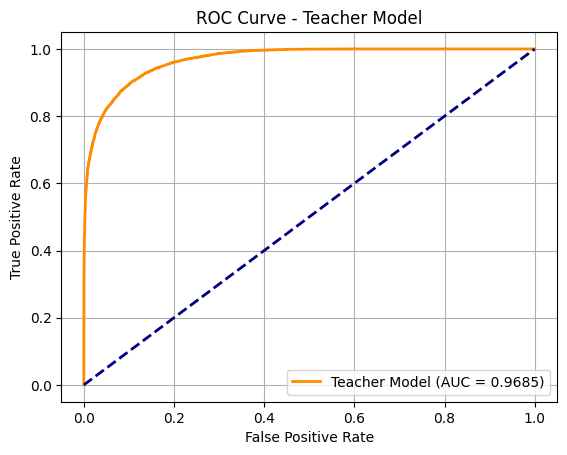

In [22]:
plot_roc_curve(student, test_loader, model_name="Student Model")
plot_roc_curve(teacher, test_loader, model_name="Teacher Model")
